In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/sachinkumar413/alzheimer-mri-dataset
License(s): copyright-authors
 93% 26.0M/28.0M [00:02<00:00, 17.9MB/s]
100% 28.0M/28.0M [00:02<00:00, 11.4MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/alzheimer-mri-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage.io
import os
import tqdm
import glob
import tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.data.experimental import AUTOTUNE
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import RandomRotation, RandomZoom
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras import applications
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

!pip install split-folders
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import regularizers #import regularizers

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow
from skimage.transform import resize

from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import Precision, AUC,Recall
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
import copy
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import cv2
import keras
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report
from keras.applications.vgg16 import VGG16,preprocess_input
from keras.applications.vgg19 import VGG19,preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
import splitfolders

input_folder='/content/Dataset'

output_folder='/content/sample_data'

train_ratio=0.8
validation_ratio=0.1
test_ratio=0.1
splitfolders.ratio(input_folder, output_folder, seed=42,
                   ratio=(train_ratio,
                          validation_ratio,
                          test_ratio))

Copying files: 6400 files [00:00, 6882.54 files/s]


In [ ]:
from keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE=16
IMG_SIZE=(224,224)
SEED=1345 # to ensure that the same sequence of images is generated each time the code is run

train_datagen=ImageDataGenerator(rescale=1./255,
                                shear_range=0,
                                zoom_range=0.2)

validation_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
train_dir='/content/sample_data/train'
val_dir='/content/sample_data/val'
test_dir='/content/sample_data/test'

In [ ]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
        target_size=(224, 224), #to which image should be resized
        shuffle=True,
        seed = SEED,
        batch_size=16, #no. of images to include in each batch
        class_mode ='categorical',
)

validation_generator = validation_datagen.flow_from_directory(
        val_dir,
        target_size=(224, 224),
        seed = SEED,
        shuffle=True,
        batch_size=16,
        class_mode ='categorical',)

test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        shuffle=True,
        seed = SEED,
        batch_size = 16,
        class_mode ='categorical',
)


Found 5119 images belonging to 4 classes.
Found 639 images belonging to 4 classes.
Found 642 images belonging to 4 classes.


In [ ]:

def data_augmentar():
    data_augmentation = Sequential()
    data_augmentation.add(RandomRotation(factor=(-0.3, 0.3)))  # Increased rotation range
    data_augmentation.add(RandomZoom((-0.4, -0.2)))  # Increased zoom range
    return data_augmentation

data_augmentation = data_augmentar()
assert(data_augmentation.layers[0].name.startswith('random_rotation'))
assert(data_augmentation.layers[0].factor == (-0.3, 0.3))  # Updated rotation range assertion
assert(data_augmentation.layers[1].name.startswith('random_zoom'))
assert(data_augmentation.layers[1].height_factor == (-0.4, -0.2))

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
vgg = VGG19(weights='imagenet',
            include_top = False,input_shape=(224, 224, 3)
           )
for layer in vgg.layers:
    layer.trainable = False
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense
model = Sequential()
model.add(vgg)
model.add(Flatten())
model.add(Dense(4,activation="softmax"))

80134624/80134624 [==============================] - 4s 0us/step


In [ ]:
filepath = './Vgg_best_weights.hdf5'
earlystopping=EarlyStopping(monitor='val_accuracy',
                           mode='max',
                           patience=15,
                           verbose=1)

checkpoint=ModelCheckpoint(filepath,monitor = 'val_accuracy',
                                mode='max',
                                save_best_only=True,
                                verbose = 1)

callback_list=[earlystopping,checkpoint]

In [ ]:
model.compile(optimizer=Adam( lr= 0.001), loss='categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(),
                        tf.keras.metrics.Precision(),
                        tf.keras.metrics.Recall(),])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 4)                 100356    
                                                                 
Total params: 20124740 (76.77 MB)
Trainable params: 100356 (392.02 KB)
Non-trainable params: 20024384 (76.39 MB)
_________________________________________________________________


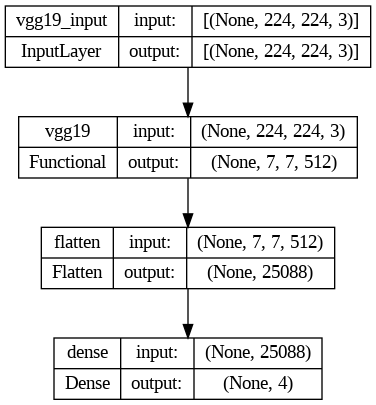

In [ ]:
from keras.utils import plot_model
plot_model(model, show_shapes=True)

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler
def scheduler(epoch, lr):
  if epoch <= 3:
    return lr
  else:
    return lr * tf.math.exp(-0.1)

In [ ]:
lr = 0.001
for i in range(10):
  lr = scheduler(i, lr)
  print(lr)

0.001
0.001
0.001
0.001
tf.Tensor(0.0009048374, shape=(), dtype=float32)
tf.Tensor(0.0008187307, shape=(), dtype=float32)
tf.Tensor(0.0007408181, shape=(), dtype=float32)
tf.Tensor(0.0006703199, shape=(), dtype=float32)
tf.Tensor(0.00060653046, shape=(), dtype=float32)
tf.Tensor(0.00054881145, shape=(), dtype=float32)


In [ ]:
history=model.fit(train_generator,
                        validation_data=validation_generator,
                        steps_per_epoch=len(train_generator),
                        epochs = 50,
                        verbose = 1,
              callbacks = callback_list)

Epoch 1/50
320/320 [==============================] - ETA: 0s - loss: 1.2149 - accuracy: 0.5413 - auc: 0.8062 - precision: 0.5609 - recall: 0.4892
Epoch 1: val_accuracy improved from -inf to 0.53208, saving model to ./Vgg_best_weights.hdf5
320/320 [==============================] - 93s 264ms/step - loss: 1.2149 - accuracy: 0.5413 - auc: 0.8062 - precision: 0.5609 - recall: 0.4892 - val_loss: 1.0981 - val_accuracy: 0.5321 - val_auc: 0.8281 - val_precision: 0.5577 - val_recall: 0.4992
Epoch 2/50
320/320 [==============================] - ETA: 0s - loss: 0.8655 - accuracy: 0.6492 - auc: 0.8827 - precision: 0.6725 - recall: 0.6042
Epoch 2: val_accuracy improved from 0.53208 to 0.65415, saving model to ./Vgg_best_weights.hdf5
320/320 [==============================] - 81s 252ms/step - loss: 0.8655 - accuracy: 0.6492 - auc: 0.8827 - precision: 0.6725 - recall: 0.6042 - val_loss: 0.7795 - val_accuracy: 0.6541 - val_auc: 0.8970 - val_precision: 0.6794 - val_recall: 0.6103
Epoch 3/50
320/320 [=

In [ ]:
result = model.evaluate(train_generator)
train_loss = result[0]
train_accuracy = result[1]
train_AUC = result[2]
train_pre = result[3]
train_rec = result[4]
print(f'Train Loss = {train_loss}')
print(f'Train Accuracy = {train_accuracy}')
print(f'Train AUC = {train_AUC}')
print(f'Train Precision = {train_pre}')
print(f'Train Recall = {train_rec}')

In [ ]:
result = model.evaluate(test_generator)
test_loss = result[0]
test_accuracy = result[1]
test_AUC = result[2]
test_pre = result[3]
test_rec = result[4]
print(f'Test Loss = {test_loss}')
print(f'Test Accuracy = {test_accuracy}')
print(f'Test AUC = {test_AUC}')
print(f'Test Precision = {test_pre}')
print(f'Test Recall = {test_rec}')

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
test_label=test_generator.classes

In [ ]:
Y_pred=model.predict(test_generator)

In [ ]:
y_pred=[]
[y_pred.append(np.argmax(I)) for I in Y_pred ]

In [ ]:
confusion_matrix(test_label, y_pred)


In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, cmap=plt.cm.Blues):
    if normalize:
#         cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = "Normalized Confusion Matrix"
    else:
        title = "Confusion Matrix"

    plt.imshow(cm, interpolation='nearest', cmap= cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
#     '.2f' if normalize else
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(test_label, y_pred)

class_names=list(train_generator.class_indices.keys())
print(class_names)

plt.figure(figsize=(8, 6))
plot_confusion_matrix(cm, class_names, normalize=True)
plt.show()

In [ ]:
report = classification_report(test_label, y_pred)
print("Classification Report:")
print(report)

In [ ]:
import cv2

In [ ]:
test_image = cv2.imread('/content/moderate_13.jpg')

In [ ]:
plt.imshow(test_image)

In [ ]:
test_image.shape

In [ ]:
test_image = cv2.resize(test_image,(224,224))

In [ ]:
test_input = test_image.reshape((1,224,224,3))

In [ ]:
model.predict(test_input)

In [ ]:
model.compile(optimizer=Adam( lr= 0.001), loss='categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(),
                        tf.keras.metrics.Precision(),
                        tf.keras.metrics.Recall(),])

In [ ]:
model.summary()

In [ ]:
from keras.utils import plot_model
plot_model(model, show_shapes=True)

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler
def scheduler(epoch, lr):
  if epoch <= 3:
    return lr
  else:
    return lr * tf.math.exp(-0.1)

In [ ]:
lr = 0.001
for i in range(10):
  lr = scheduler(i, lr)
  print(lr)

In [ ]:
history=model.fit(train_generator,
                        validation_data=validation_generator,
                        steps_per_epoch=len(train_generator),
                        epochs = 50,
                        verbose = 1,
              callbacks = callback_list)

In [ ]:
result = model.evaluate(train_generator)
train_loss = result[0]
train_accuracy = result[1]
train_AUC = result[2]
train_pre = result[3]
train_rec = result[4]
print(f'Train Loss = {train_loss}')
print(f'Train Accuracy = {train_accuracy}')
print(f'Train AUC = {train_AUC}')
print(f'Train Precision = {train_pre}')
print(f'Train Recall = {train_rec}')

In [ ]:
result = model.evaluate(test_generator)
test_loss = result[0]
test_accuracy = result[1]
test_AUC = result[2]
test_pre = result[3]
test_rec = result[4]
print(f'Test Loss = {test_loss}')
print(f'Test Accuracy = {test_accuracy}')
print(f'Test AUC = {test_AUC}')
print(f'Test Precision = {test_pre}')
print(f'Test Recall = {test_rec}')

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend('train', 'val')
plt.show()

In [ ]:
test_label=test_generator.classes

In [ ]:
Y_pred=model.predict(test_generator)

In [ ]:
y_pred=[]
[y_pred.append(np.argmax(I)) for I in Y_pred ]

In [ ]:
confusion_matrix(test_label, y_pred)


In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, cmap=plt.cm.Blues):
    if normalize:
#         cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = "Normalized Confusion Matrix"
    else:
        title = "Confusion Matrix"

    plt.imshow(cm, interpolation='nearest', cmap= cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
#     '.2f' if normalize else
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(test_label, y_pred)

class_names=list(train_generator.class_indices.keys())
print(class_names)

plt.figure(figsize=(8, 6))
plot_confusion_matrix(cm, class_names, normalize=True)
plt.show()

In [ ]:
report = classification_report(test_label, y_pred)
print("Classification Report:")
print(report)

In [ ]:
import cv2

In [ ]:
test_image = cv2.imread('/content/moderate_13.jpg')

In [ ]:
plt.imshow(test_image)

In [ ]:
test_image.shape

In [ ]:
test_image = cv2.resize(test_image,(224,224))

In [ ]:
test_input = test_image.reshape((1,224,224,3))

In [ ]:
model.predict(test_input)